<a href="https://colab.research.google.com/github/Karthik5412/Deep-Learning-Projects/blob/main/CNN/animals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Download the 10 Animals dataset
!kaggle datasets download -d alessiocorrado99/animals10

# Unzip it quietly (-q) into a dedicated folder
!unzip -q animals10.zip -d ./wild_animals

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:19<00:00, 31.3MB/s]



In [2]:
import os

dataset_path = "./wild_animals/raw-img"

if os.path.exists(dataset_path):
    animal_folders = os.listdir(dataset_path)
    print(f"📊 Success! Found {len(animal_folders)} animal classes.")
    print("Your directories:")
    for folder in animal_folders:
        # Count how many images are in each folder
        num_images = len(os.listdir(os.path.join(dataset_path, folder)))
        print(f"  • {folder}: {num_images} images")
else:
    print("Could not find the path. Run a quick !ls to check where it unzipped!")

📊 Success! Found 10 animal classes.
Your directories:
  • pecora: 1820 images
  • scoiattolo: 1862 images
  • farfalla: 2112 images
  • gallina: 3098 images
  • cavallo: 2623 images
  • mucca: 1866 images
  • elefante: 1446 images
  • gatto: 1668 images
  • cane: 4863 images
  • ragno: 4821 images


In [3]:
translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel",
    "ragno": "spider"
}

# **My Code From Here**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [20]:
train_ds = image_dataset_from_directory("/content/wild_animals/raw-img",labels='inferred',label_mode='int', color_mode='rgb',image_size=(256,256), shuffle=True,validation_split=0.2 ,seed=123,subset='training')

val_ds = image_dataset_from_directory("/content/wild_animals/raw-img",labels='inferred',label_mode='int', color_mode='rgb',image_size=(256,256), shuffle=True, validation_split=0.2,seed=123,subset='validation')

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


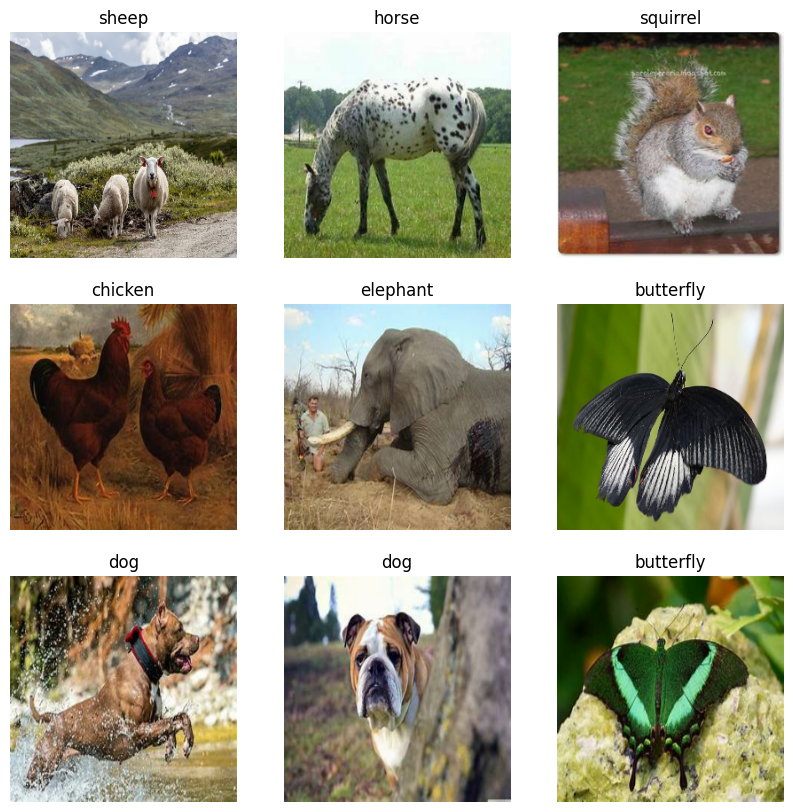

In [22]:
plt.figure(figsize=(10,10))

class_names = train_ds.class_names

for img,label in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(translate[class_names[label[i]]])
        plt.axis('off')

plt.show()

In [17]:
train_ds.class_names

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']